# Concensus NMF running script

#### similar as described by cNMF team on github: https://github.com/dylkot/cNMF/blob/master/Tutorials/analyze_pbmc_example_data.ipynb

In [1]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
#from IPython.display import Imaged
import scanpy as sc
from cnmf import cNMF
import anndata as ad

np.random.seed(42)

In [5]:
all_norm = pd.read_csv('../data/RNA_normed_counts_final.csv')
all_norm = all_norm.drop(columns=['Unnamed: 0'])
all_meta = pd.read_csv('../data/RNA_meta_final.csv')
all_meta = all_meta.drop(columns=['Unnamed..0'])
all_norm.head()

,AATK,ABL1,ABL2,ACE,ACE2,ACKR1,ACKR3,ACKR4,ACTA2,ACTG2,...,WNT5B,WNT7A,WNT7B,WNT9A,XBP1,XCL1,XCL2,YBX3,YES1,ZFP36
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.751938,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [6]:
all_meta.head()

,X,orig.ident,nCount_RNA,nFeature_RNA,fov,cellLabel,cellSize,cent_X,cent_Y,width,...,benign epithelium,carcinoma,endometrial stroma,myometrium,sarcoma NOS,rhabdomyosarcoma,LVSI,other,ann,MS
0,0,SeuratProject,120,64,2,2,8460,1929,35,250,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
1,1,SeuratProject,30,26,2,3,1152,176,10,66,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
2,2,SeuratProject,49,36,2,4,1320,1035,10,74,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
3,3,SeuratProject,129,77,2,5,1856,2677,15,68,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
4,4,SeuratProject,34,25,2,6,524,919,10,28,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53


In [7]:
all_meta.annV7_noNum.value_counts()

Carcinoma                   84037
Sarcoma                     75625
Ambiguous                   20351
Benign Stroma               17537
Macrophage/DC               16603
Myometrium                  10642
Endothelial                 10251
Plasma/B                     6813
T                            6296
Benign Endometrial gland     1056
Undif Carci                   759
Name: annV7_noNum, dtype: int64

In [9]:
norm_sub = all_norm.loc[all_meta.annV7_noNum == 'Macrophage/DC']
meta_sub = all_meta.loc[all_meta.annV7_noNum == 'Macrophage/DC']
norm_sub.shape

(16603, 979)

In [10]:
mphdc = ad.AnnData(
    norm_sub.to_numpy(), dtype=np.float32
)
save = '../data/for_mphdc_cnmf_sub.h5ad'
sc.write(save, mphdc)
mphdc

AnnData object with n_obs × n_vars = 16603 × 979

In [11]:
numiter=200 # Number of NMF replicates. Set this to a larger value ~200 for real data. We set this to a relatively low value here for illustration at a faster speed
numhvgenes=979 ## Number of over-dispersed genes to use for running the actual factorizations

## Results will be saved to [output_directory]/[run_name] which in this example is example_PBMC/cNMF/pbmc_cNMF
output_directory = '../data/cnmf_mphdc/'
if not os.path.exists(output_directory):
    os.mkdir(output_directory)
run_name = 'cnmf_res1'

## Specify the Ks to use as a space separated list in this case "5 6 7 8 9 10"
K = ' '.join([str(i) for i in range(5,26, 5)])

seed = 42 ## Specify a seed pseudorandom number generation for reproducibility

In [12]:
K # search

'5 10 15 20 25'

In [13]:
## Initialize the cnmf object that will be used to run analyses
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)

In [14]:
## Prepare the data, I.e. subset to 2000 high-variance genes, and variance normalize
cnmf_obj.prepare(counts_fn=save, components=range(5,26, 5), #directly do?
                 n_iter=numiter, seed=seed, num_highvar_genes=numhvgenes)

In [15]:
## Specify that the jobs are being distributed over a single worker (total_workers=1) and then launch that worker
# this took 33 hours on full dataset
cnmf_obj.factorize(worker_i=0, total_workers=2)

[Worker 0]. Starting task 0.
[Worker 0]. Starting task 2.
[Worker 0]. Starting task 4.
[Worker 0]. Starting task 6.
[Worker 0]. Starting task 8.
[Worker 0]. Starting task 10.
[Worker 0]. Starting task 12.
[Worker 0]. Starting task 14.
[Worker 0]. Starting task 16.
[Worker 0]. Starting task 18.
[Worker 0]. Starting task 20.
[Worker 0]. Starting task 22.
[Worker 0]. Starting task 24.
[Worker 0]. Starting task 26.
[Worker 0]. Starting task 28.
[Worker 0]. Starting task 30.
[Worker 0]. Starting task 32.
[Worker 0]. Starting task 34.
[Worker 0]. Starting task 36.
[Worker 0]. Starting task 38.
[Worker 0]. Starting task 40.
[Worker 0]. Starting task 42.
[Worker 0]. Starting task 44.
[Worker 0]. Starting task 46.
[Worker 0]. Starting task 48.


/Users/bokaizhu/anaconda3/envs/cnmf_env/lib/python3.7/site-packages/sklearn/decomposition/_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  ConvergenceWarning,


[Worker 0]. Starting task 50.
[Worker 0]. Starting task 52.
[Worker 0]. Starting task 54.
[Worker 0]. Starting task 56.
[Worker 0]. Starting task 58.
[Worker 0]. Starting task 60.
[Worker 0]. Starting task 62.
[Worker 0]. Starting task 64.
[Worker 0]. Starting task 66.
[Worker 0]. Starting task 68.
[Worker 0]. Starting task 70.
[Worker 0]. Starting task 72.
[Worker 0]. Starting task 74.
[Worker 0]. Starting task 76.
[Worker 0]. Starting task 78.
[Worker 0]. Starting task 80.
[Worker 0]. Starting task 82.
[Worker 0]. Starting task 84.
[Worker 0]. Starting task 86.
[Worker 0]. Starting task 88.
[Worker 0]. Starting task 90.
[Worker 0]. Starting task 92.
[Worker 0]. Starting task 94.
[Worker 0]. Starting task 96.
[Worker 0]. Starting task 98.
[Worker 0]. Starting task 100.
[Worker 0]. Starting task 102.
[Worker 0]. Starting task 104.
[Worker 0]. Starting task 106.
[Worker 0]. Starting task 108.
[Worker 0]. Starting task 110.
[Worker 0]. Starting task 112.
[Worker 0]. Starting task 114.
[W

/Users/bokaizhu/anaconda3/envs/cnmf_env/lib/python3.7/site-packages/sklearn/decomposition/_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  ConvergenceWarning,


[Worker 0]. Starting task 122.
[Worker 0]. Starting task 124.
[Worker 0]. Starting task 126.
[Worker 0]. Starting task 128.
[Worker 0]. Starting task 130.
[Worker 0]. Starting task 132.
[Worker 0]. Starting task 134.
[Worker 0]. Starting task 136.
[Worker 0]. Starting task 138.
[Worker 0]. Starting task 140.
[Worker 0]. Starting task 142.
[Worker 0]. Starting task 144.
[Worker 0]. Starting task 146.
[Worker 0]. Starting task 148.
[Worker 0]. Starting task 150.
[Worker 0]. Starting task 152.
[Worker 0]. Starting task 154.
[Worker 0]. Starting task 156.


...

[Worker 0]. Starting task 968.
[Worker 0]. Starting task 970.
[Worker 0]. Starting task 972.
[Worker 0]. Starting task 974.
[Worker 0]. Starting task 976.


/Users/bokaizhu/anaconda3/envs/cnmf_env/lib/python3.7/site-packages/sklearn/decomposition/_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  ConvergenceWarning,


[Worker 0]. Starting task 978.
[Worker 0]. Starting task 980.
[Worker 0]. Starting task 982.


/Users/bokaizhu/anaconda3/envs/cnmf_env/lib/python3.7/site-packages/sklearn/decomposition/_nmf.py:1641: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  ConvergenceWarning,


[Worker 0]. Starting task 984.
[Worker 0]. Starting task 986.
[Worker 0]. Starting task 988.
[Worker 0]. Starting task 990.
[Worker 0]. Starting task 992.
[Worker 0]. Starting task 994.
[Worker 0]. Starting task 996.
[Worker 0]. Starting task 998.


In [16]:
cnmf_obj.combine(skip_missing_files=True)

Combining factorizations for k=5.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_1.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_3.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_5.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_7.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_9.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_11.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_13.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_15.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k_5.iter_17.df.npz. Skipping.
Missing file: ../data/cnmf_mphdc/cnmf_res1/cnmf_tmp/cnmf_res1.spectra.k

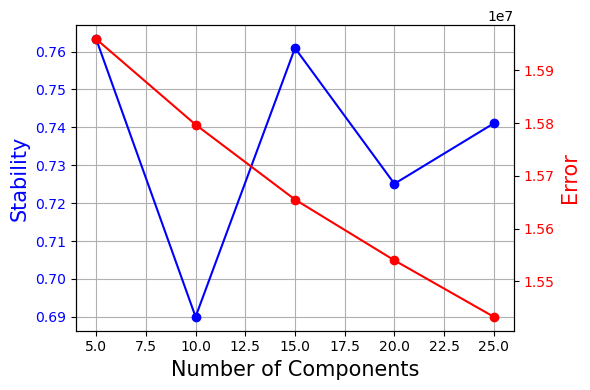

In [17]:
## previouslly test 5-20
cnmf_obj.k_selection_plot(close_fig=False)
# what do we pick hmm

In [18]:
selected_K = 15
density_threshold = 2.00

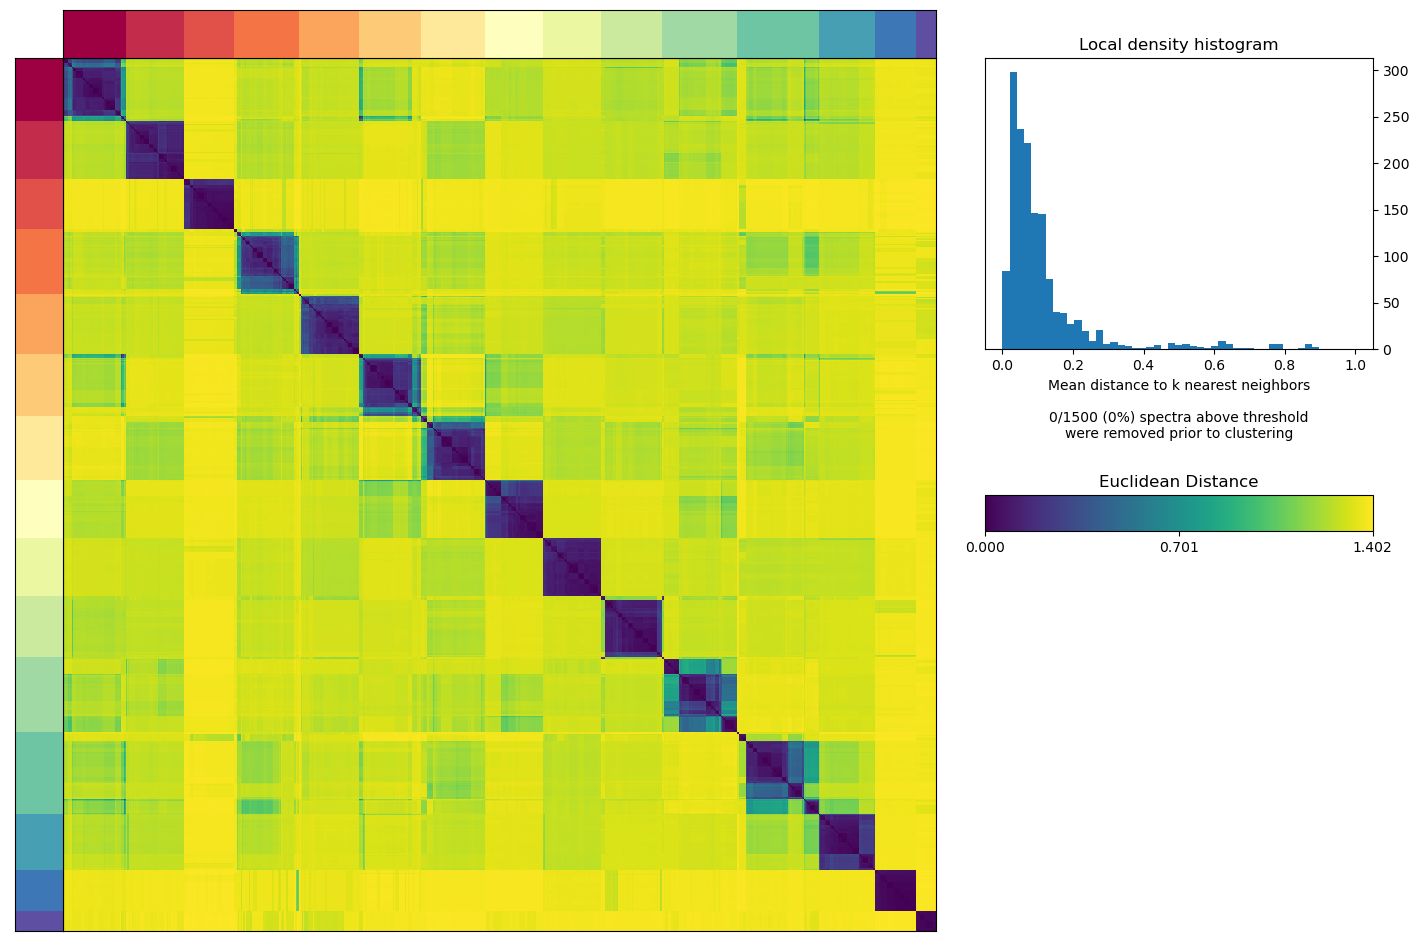

In [19]:
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)

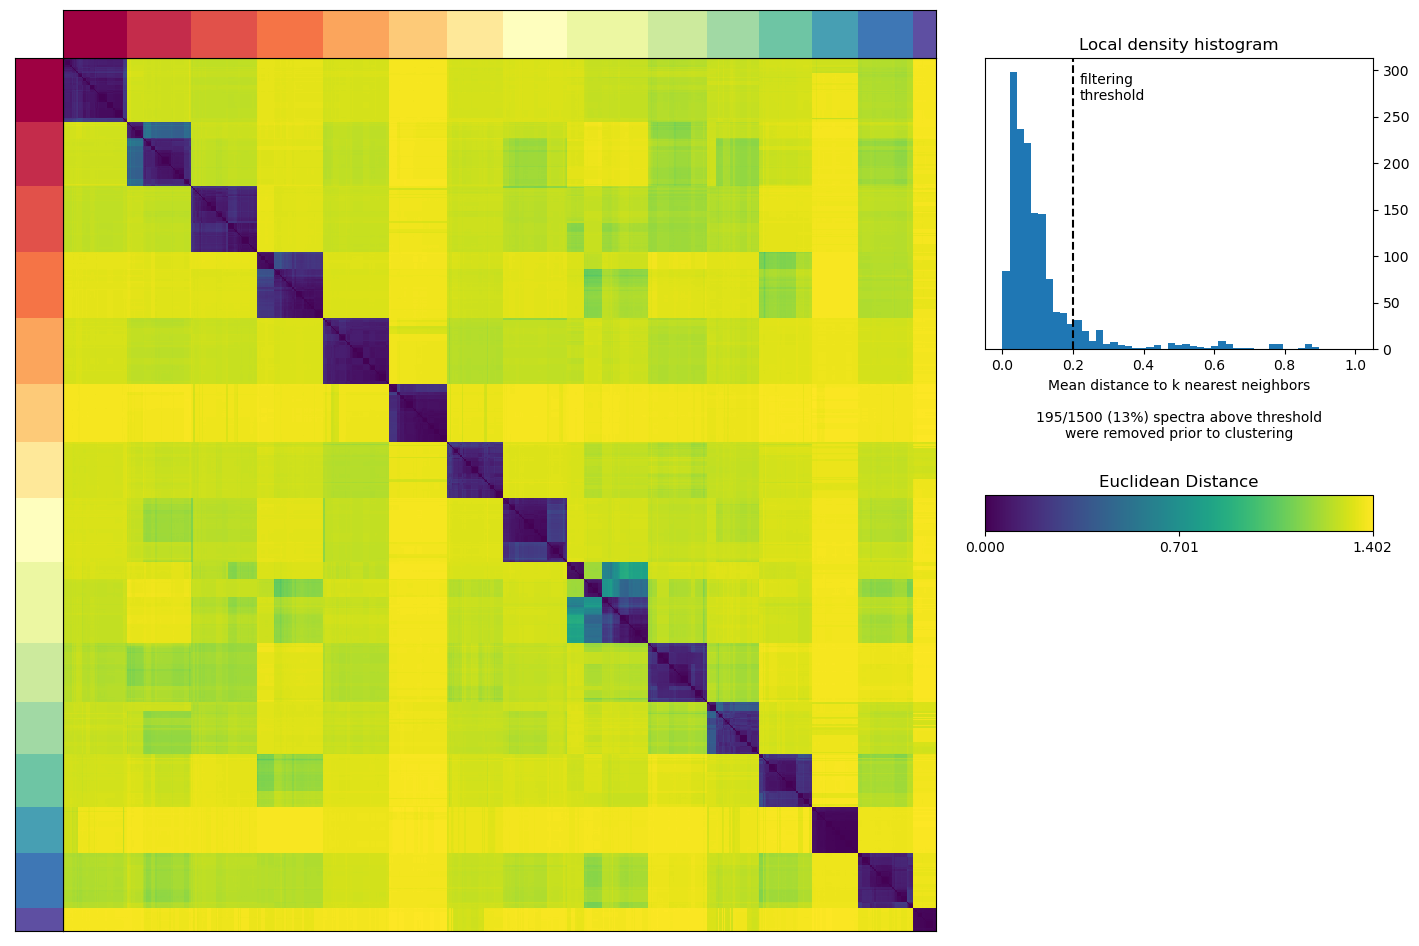

In [20]:
density_threshold = 0.2
cnmf_obj.consensus(k=selected_K, density_threshold=density_threshold, show_clustering=True, close_clustergram_fig=False)


Load cnmf results here

In [21]:
usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)
usage_norm.columns = ['Usage_%d' % i for i in usage_norm.columns]
usage_norm

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_8,Usage_9,Usage_10,Usage_11,Usage_12,Usage_13,Usage_14,Usage_15
0,0.000000,0.000000,0.000000,0.188844,0.122005,0.242909,0.070965,0.080991,0.000000,0.000000,0.000000,0.294286,0.000000,0.000000,0.000000
1,0.000000,0.096863,0.255903,0.267469,0.022274,0.073164,0.034857,0.042341,0.000000,0.096077,0.000000,0.090198,0.020853,0.000000,0.000000
2,0.010701,0.000000,0.139088,0.108817,0.066237,0.174538,0.072121,0.098890,0.008504,0.168930,0.074587,0.060704,0.000343,0.016541,0.000000
3,0.198690,0.027439,0.047436,0.000000,0.429746,0.039583,0.205592,0.000000,0.018245,0.029335,0.002429,0.000000,0.000000,0.000000,0.001505
4,0.123244,0.166122,0.075286,0.308563,0.107332,0.027593,0.096109,0.000904,0.000000,0.000000,0.000000,0.091257,0.000000,0.003591,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16598,0.038144,0.334116,0.240928,0.000000,0.155487,0.115912,0.000000,0.000000,0.053404,0.000000,0.000000,0.037685,0.009181,0.015143,0.000000
16599,0.476891,0.077365,0.000000,0.049365,0.226486,0.145097,0.000000,0.000629,0.000000,0.000000,0.000000,0.000000,0.024169,0.000000,0.000000
16600,0.553868,0.014075,0.004159,0.022073,0.178508,0.039698,0.128681,0.000000,0.000000,0.000000,0.040995,0.000000,0.017777,0.000165,0.000000
16601,0.000000,0.343852,0.143949,0.071674,0.027137,0.099746,0.048711,0.000000,0.060139,0.020669,0.000000,0.073790,0.005712,0.104620,0.000000


In [23]:
usage_norm.to_csv('../data/mphDC_cnmf15_usage.csv')

In [24]:
dd = {}
genelist = norm_sub.columns.tolist()
for i in range(10):
    dd[i] = []
    for j in range(100):
        id = int(topgenes.iloc[j,i])
        gene = genelist[id]
        dd[i].append(gene)
df = pd.DataFrame.from_dict(dd)
df

,0,1,2,3,4,5,6,7,8,9
0,TUBB,CD74,MALAT1,HLA.C,COL9A2,HSP90AB1,IGHG1,COL3A1,SPP1,TAGLN
1,STMN1,C1QC,NEAT1,C1QA,NPPC,MIF,IGKC,COL1A1,MMP12,BGN
2,TWIST1,C1QB,RGS1,HLA.B,MZT2A,HSPA1A,CXCL9,COL1A2,CD52,IGFBP7
3,CALM2,SELENOP,ZFP36,B2M,AZU1,HSPA1B,IGHG2,IGF2,MMP9,LUM
4,RPL21,HLA.DRA,FOS,PSAP,DUSP5,HSP90AA1,CXCL10,DCN,SLC2A1,SPARCL1
...,...,...,...,...,...,...,...,...,...,...
95,FZD1,IL23A,HLA.DRB1,IFNGR2,CCL26,CSK,CCR7,FGF2,EFNB2,PGF
96,EFNA4,SIGIRR,ETV5,ENG,FLT3LG,DUSP6,CASP3,JAG1,RUNX3,STAT5B
97,COL5A1,GZMA,MRC1,OAS2,IL2,IGF1R,NRXN3,CXCL12,IL20RA,PLA2R1
98,NOTCH2,CHGA,TXK,ADGRE5,GC,RELA,KLK3,PDGFA,HSD17B2,BMP6


In [25]:
df.to_csv('../data/top100g_mphdc_cnmf15.csv', index = False)

In [26]:
## also consider saving the gene_spectra_score (aka gene loading for the GEPs)
gep_scores.index = norm_sub.columns
gep_scores.to_csv('../data/gspec_mphdc_cnmf15.csv')
gep_scores

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
AATK,0.001383,-0.000184,0.000906,-0.001291,0.000646,-0.001402,-0.000507,-0.000599,-0.000040,0.000182,0.000329,-0.000761,0.002083,-0.000577,-0.000334
ABL1,0.000342,-0.001265,-0.000741,0.000015,0.001042,0.000676,-0.000373,0.000598,-0.001006,0.000025,-0.000338,0.000094,-0.000211,-0.000091,0.007452
ABL2,0.000673,-0.001190,0.001814,-0.000716,-0.000973,-0.001051,0.000820,0.000730,0.000269,-0.000722,0.000993,-0.000148,-0.000651,-0.000289,0.000778
ACE,-0.000310,-0.001047,0.000449,-0.000062,-0.000750,0.000752,0.002887,0.000095,-0.000850,0.000005,0.000051,-0.001084,-0.000004,0.000111,-0.000881
ACE2,-0.000239,-0.001010,0.001459,-0.001020,0.000102,-0.000079,0.000145,-0.000241,0.000388,0.000348,0.000481,0.000262,0.001384,0.000590,-0.001113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XCL1,0.000762,0.000269,-0.000899,-0.001122,-0.000507,-0.000426,0.001864,-0.000635,0.000688,-0.000652,0.000050,-0.000268,0.001680,0.001934,0.001142
XCL2,0.000491,-0.001013,0.001195,-0.001068,0.000846,-0.000078,0.000689,-0.000238,-0.000473,-0.000896,0.000182,-0.000300,-0.000957,-0.000899,0.003065
YBX3,0.005274,-0.001040,-0.001094,-0.002626,-0.001557,0.001438,-0.000898,-0.002197,-0.001609,0.003789,-0.001349,0.001685,-0.001650,-0.001598,0.001754
YES1,0.002332,-0.001192,-0.000033,-0.000196,-0.000644,0.002705,-0.000923,-0.000524,-0.000268,-0.001351,-0.001041,-0.001083,0.000509,0.000860,-0.000749


In [27]:
## also need to save the meta files
meta_sub.to_csv('../data/mphdc_cnmf_meta.csv')

In [28]:
meta_sub

,X,orig.ident,nCount_RNA,nFeature_RNA,fov,cellLabel,cellSize,cent_X,cent_Y,width,...,benign epithelium,carcinoma,endometrial stroma,myometrium,sarcoma NOS,rhabdomyosarcoma,LVSI,other,ann,MS
2,2,SeuratProject,49,36,2,4,1320,1035,10,74,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
28,28,SeuratProject,463,196,2,32,4452,1096,46,60,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
34,34,SeuratProject,347,196,2,38,8716,832,56,100,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
38,38,SeuratProject,46,37,2,44,2428,980,56,62,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
47,47,SeuratProject,48,28,2,55,1388,982,92,50,...,0,1,0,1,0,0,1,NaN,F5 High Grade,p53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249958,249960,SeuratProject,46,33,21,4485,3300,4073,4462,100,...,0,check,0,minimal,1,0,0,?sarcoma vs carcinoma,B9 HG,MMR
249961,249963,SeuratProject,29,26,21,4488,2956,970,4462,94,...,0,check,0,minimal,1,0,0,?sarcoma vs carcinoma,B9 HG,MMR
249964,249966,SeuratProject,27,24,21,4492,2244,4222,4462,66,...,0,check,0,minimal,1,0,0,?sarcoma vs carcinoma,B9 HG,MMR
249967,249969,SeuratProject,23,18,21,4499,1160,4011,4465,44,...,0,check,0,minimal,1,0,0,?sarcoma vs carcinoma,B9 HG,MMR
